### Workbook for creating maps and graphics for FOSS4G manuscript
Week of February 2, 2026 <br>
Author: Adele Birkenes

In [11]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 

Task 1: Set synced & unsynced file paths, read in needs assessment data & village boundaries, ensure CRSs match

In [3]:
# Set data path
synced_path = "../../synced-data/population-exploration"

# Set needs assessment file path
needs_assessment_fp = os.path.join(synced_path, "Rwanda Sites with All Population Fields_Exported 2025.04.11.csv")

# Read the .csv file into a dataframe with an encoding that accommodates special characters
needs_assessment_df = pd.read_csv(needs_assessment_fp, encoding='ISO-8859-1')

# Create gdf from needs assessment data, using longitude and latitude columns to create Point geometries
geometry = [Point(xy) for xy in zip(needs_assessment_df['Bridge Opportunity: GPS (Longitude)'], needs_assessment_df['Bridge Opportunity: GPS (Latitude)'])]
needs_assessment = gpd.GeoDataFrame(needs_assessment_df, geometry=geometry, crs="EPSG:4326")

In [4]:
# Set village boundaries file path
village_boundaries_fp = os.path.join(synced_path, "Rwanda Village Boundaries/Village.shp")

# Read shp into a gdf
village_boundaries = gpd.read_file(village_boundaries_fp)

In [5]:
# Set needs assessment gdf CRS to that of village boundaries
needs_assessment = needs_assessment.to_crs(village_boundaries.crs)
print(needs_assessment.crs)

PROJCS["TM_Rwanda",GEOGCS["ITRF2005",DATUM["International_Terrestrial_Reference_Frame_2005",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6896"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


Task 2: Dissolve village boundaries gdf to create admin 1-4 boundaries

In [6]:
# Dissolve village boundaries gdf to create gdfs for admin 1-4 boundaries
def dissolve_boundaries(admin_level, village_boundaries=village_boundaries):
    # Dissolve the village boundaries by the specified admin level
    dissolved_boundaries = village_boundaries.dissolve(by=admin_level)
    dissolved_boundaries.reset_index(inplace=True)

    # Remove unneeded admin columns (e.g., 'Village_ID' for admin level 4)
    if admin_level == 'Cell_ID':
        dissolved_boundaries.drop(columns=['Village_ID'], inplace=True)
    if admin_level == 'Sector_ID':
        dissolved_boundaries.drop(columns=['Village_ID', 'Cell_ID'], inplace=True)
    if admin_level == 'Dist_ID':
        dissolved_boundaries.drop(columns=['Village_ID', 'Cell_ID', 'Sector_ID'], inplace=True)
    elif admin_level == 'Prov_ID':
        dissolved_boundaries.drop(columns=['Village_ID', 'Cell_ID', 'Sector_ID', 'Distr_ID'], inplace=True)

    return dissolved_boundaries

admin_1_boundaries = dissolve_boundaries(admin_level='Prov_ID')
admin_2_boundaries = dissolve_boundaries(admin_level='Distr_ID')
admin_3_boundaries = dissolve_boundaries(admin_level='Sector_ID')
admin_4_boundaries = dissolve_boundaries(admin_level='Cell_ID')

Task 3: Create a map of sites covered by needs assessments, classifying the points according to "Bridge Opportunity: Stage"

In [14]:
# Get unique values for "Bridge Opportunity: Stage" column in needs assessment gdf
needs_assessment["Bridge Opportunity: Stage"].unique()

array(['Rejected', 'Complete', 'Prospecting', 'Identified', 'Cancelled',
       'Under Construction', 'Confirmed'], dtype=object)

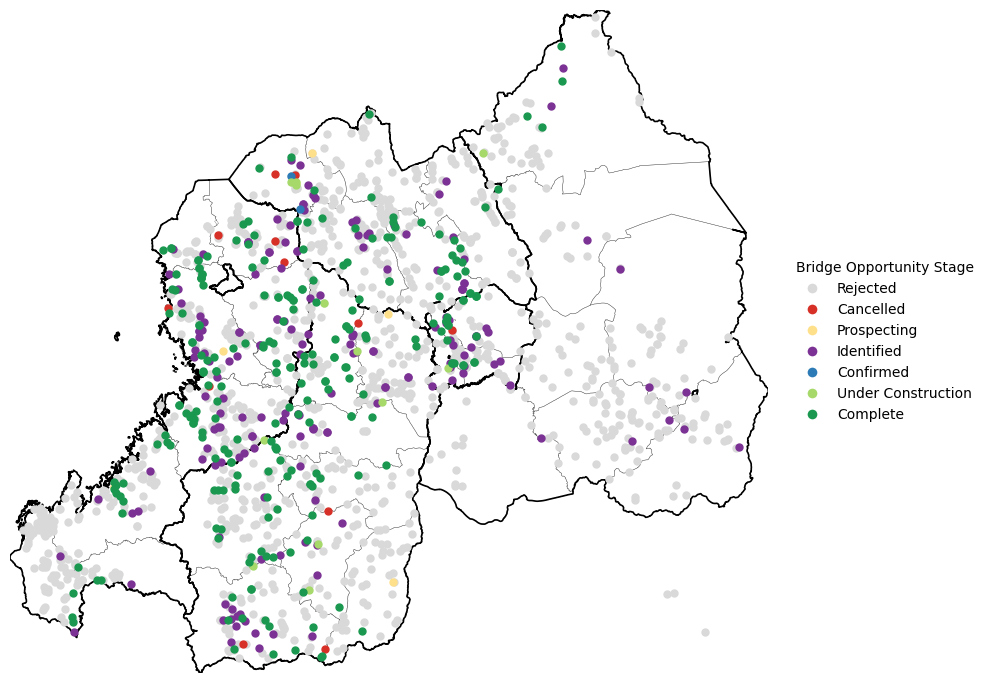

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# --- Boundaries ---
admin_2_boundaries.plot(
    ax=ax,
    linewidth=0.3,
    edgecolor="black",
    alpha=0.5,
    facecolor="none"
)

admin_1_boundaries.plot(
    ax=ax,
    linewidth=1.2,
    edgecolor="black",
    alpha=1.0,
    facecolor="none"
)

# --- Manual stage → color mapping ---
stage_colors = {
    "Cancelled":          "#d73027",
    "Complete":           "#1a9850",
    "Confirmed":          "#2c7bb6",
    "Identified":         "#7b3294",
    "Prospecting":        "#fee08b",
    "Rejected":           "#d9d9d9",
    "Under Construction": "#a6d96a"
}

# --- Draw order: bottom → top ---
plot_order = [
    "Rejected",
    "Cancelled",
    "Prospecting",
    "Identified",
    "Confirmed",
    "Under Construction",
    "Complete"
]

# --- Plot points by stage ---
for stage in plot_order:
    subset = needs_assessment[
        needs_assessment["Bridge Opportunity: Stage"] == stage
    ]

    if subset.empty:
        continue

    subset.plot(
        ax=ax,
        color=stage_colors[stage],
        markersize=25
    )

# --- Zoom to Rwanda ---
minx, miny, maxx, maxy = admin_1_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# --- Manual legend (matches colors, not alpha) ---
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=stage,
        markerfacecolor=stage_colors[stage],
        markersize=8
    )
    for stage in plot_order
]

ax.legend(
    handles=legend_elements,
    title="Bridge Opportunity Stage",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.axis("off")
plt.tight_layout()
plt.show()